# FactoryMind AI — Anomaly Detection Refinement

This notebook tests whether the raw-sensor Isolation Forest baseline is stable enough to freeze as the research specification for Anomaly Detection v1. It performs repeated unit-held-out evaluation, normal-reference sensitivity, threshold and alert stability, engine coverage, lead time, persistence, and a focused raw-versus-temporal comparison. Nothing is serialized or productionized.

## 1. Frozen Research Contract

The detector answers: **How unusual is the current engine state relative to learned normal operating behavior?** It does not estimate anomaly probability, failure risk, or RUL.

Raw RUL is derived only to construct retrospective normal-reference subsets and evaluate degradation association. It never enters a feature matrix. The main detector uses the same 14 raw sensors and Isolation Forest configuration as notebook 11: 300 trees, `max_samples='auto'`, `contamination='auto'`, all features, and deterministic random state. Scikit-learn's score direction is negated so larger means more anomalous.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
sns.set_theme(style="whitegrid", context="notebook")

TRAIN_PATH = Path("../data/raw/train_FD001.txt")
SEEDS = [42, 52, 62, 72, 82]
REFERENCE_CUTOFFS = [100, 125, 150]
BASELINE_REFERENCE = 125
QUANTILES = [0.95, 0.975, 0.99]
STAGE_ORDER = ["Healthy / early", "Degrading", "Near failure", "Critical late life"]
COLUMNS = (["unit_id", "cycle"] + [f"operational_setting_{i}" for i in range(1, 4)] + [f"sensor_{i}" for i in range(1, 22)])
RAW_FEATURES = ["sensor_2", "sensor_3", "sensor_4", "sensor_7", "sensor_8", "sensor_9", "sensor_11", "sensor_12", "sensor_13", "sensor_14", "sensor_15", "sensor_17", "sensor_20", "sensor_21"]
TEMPORAL_BASE = ["sensor_4", "sensor_7", "sensor_11", "sensor_12", "sensor_15", "sensor_21"]
TEMPORAL_ADDITIONS = [f"{sensor}_{suffix}" for sensor in TEMPORAL_BASE for suffix in ("mean_5", "delta_1")]
TEMPORAL_FEATURES = RAW_FEATURES + TEMPORAL_ADDITIONS
IF_PARAMS = dict(n_estimators=300, max_samples="auto", contamination="auto", max_features=1.0, n_jobs=-1)
print("Seeds:", SEEDS)
print("Raw features:", RAW_FEATURES)
print("Isolation Forest:", IF_PARAMS)

Seeds: [42, 52, 62, 72, 82]
Raw features: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Isolation Forest: {'n_estimators': 300, 'max_samples': 'auto', 'contamination': 'auto', 'max_features': 1.0, 'n_jobs': -1}


## 2. Load and Validate FD001

Only `train_FD001.txt` is loaded. The official test trajectories and `RUL_FD001.txt` are outside this notebook's design.

In [2]:
df = pd.read_csv(TRAIN_PATH, sep=r"\s+", header=None, names=COLUMNS)
df["raw_rul"] = df.groupby("unit_id")["cycle"].transform("max") - df["cycle"]
df["lifecycle_stage"] = pd.cut(
    df.raw_rul, bins=[-1, 30, 60, 125, np.inf],
    labels=["Critical late life", "Near failure", "Degrading", "Healthy / early"]
).astype(pd.CategoricalDtype(STAGE_ORDER, ordered=True))

assert df.shape == (20_631, 28)
assert df.unit_id.nunique() == 100
assert len([c for c in df if c.startswith("sensor_")]) == 21
assert not {"unit_id", "cycle", "raw_rul", "RUL", "capped_rul", "final_lifetime"}.intersection(RAW_FEATURES)
assert RAW_FEATURES == [c for c in COLUMNS if c in RAW_FEATURES]
print(f"Validated {len(df):,} observations from {df.unit_id.nunique()} units.")
display(df.groupby("lifecycle_stage", observed=True).size().rename("observations").to_frame())

Validated 20,631 observations from 100 units.


,observations
lifecycle_stage,
Healthy / early,8031
Degrading,6500
Near failure,3000
Critical late life,3100


## 3. Lifecycle Bins Versus Normal-Reference Assumptions

The lifecycle bins remain frozen for evaluation: healthy/early >125 RUL, degrading 61–125, near failure 31–60, and critical late life 0–30. Separately, normal-reference sensitivity tests `raw_rul > 100`, `>125`, and `>150`. These cutoffs change which development rows fit the scaler and detector; they do not change evaluation bins. None is selected by maximizing held-out performance.

In [3]:
def add_temporal_features(frame):
    out = frame.sort_values(["unit_id", "cycle"]).copy()
    grouped = out.groupby("unit_id", sort=False)
    for sensor in TEMPORAL_BASE:
        out[f"{sensor}_mean_5"] = grouped[sensor].transform(lambda x: x.rolling(5, min_periods=1).mean())
        out[f"{sensor}_delta_1"] = grouped[sensor].diff().fillna(0.0)
    return out

df_temporal = add_temporal_features(df)
for unit, group in df_temporal.groupby("unit_id"):
    assert np.allclose(group.sensor_4_mean_5, group.sensor_4.rolling(5, min_periods=1).mean())
    assert np.allclose(group.sensor_4_delta_1, group.sensor_4.diff().fillna(0))
assert not {"unit_id", "cycle", "raw_rul"}.intersection(TEMPORAL_FEATURES)
print(f"Backward-looking temporal contract validated: {len(TEMPORAL_FEATURES)} predictors.")

Backward-looking temporal contract validated: 26 predictors.


## 4. Repeated Unit-Level Evaluation

Five predefined `GroupShuffleSplit` partitions hold out 20 entire engines each. For every split and reference assumption, separate raw and temporal scalers and detectors are fitted only on qualifying rows from the 80 development engines. Candidate thresholds are derived only from corresponding training-normal anomaly scores.

In [4]:
def fit_detector(train_normal, heldout, features, seed):
    scaler = StandardScaler().fit(train_normal[features])
    x_train = scaler.transform(train_normal[features])
    x_heldout = scaler.transform(heldout[features])
    detector = IsolationForest(random_state=seed, **IF_PARAMS).fit(x_train)
    train_scores = -detector.score_samples(x_train)
    heldout_scores = -detector.score_samples(x_heldout)
    assert scaler.n_samples_seen_ == len(train_normal)
    return scaler, detector, train_scores, heldout_scores

metric_records, threshold_records, alert_records, score_distribution_records = [], [], [], []
split_cache = {}

for seed in SEEDS:
    splitter = GroupShuffleSplit(n_splits=1, test_size=.20, random_state=seed)
    train_idx, held_idx = next(splitter.split(df, groups=df.unit_id))
    train_units = set(df.iloc[train_idx].unit_id.unique())
    held_units = set(df.iloc[held_idx].unit_id.unique())
    assert len(train_units) == 80 and len(held_units) == 20 and train_units.isdisjoint(held_units)
    raw_train = df[df.unit_id.isin(train_units)]
    raw_held = df[df.unit_id.isin(held_units)].copy()
    temporal_train = df_temporal[df_temporal.unit_id.isin(train_units)]
    temporal_held = df_temporal[df_temporal.unit_id.isin(held_units)].copy()
    split_cache[seed] = {"train_units": train_units, "held_units": held_units, "raw_held": raw_held}

    for cutoff in REFERENCE_CUTOFFS:
        for detector_name, train_frame, held_frame, features in [
            ("Raw Isolation Forest", raw_train, raw_held, RAW_FEATURES),
            ("Temporal Isolation Forest", temporal_train, temporal_held, TEMPORAL_FEATURES),
        ]:
            normal = train_frame[train_frame.raw_rul > cutoff]
            scaler, detector, train_scores, held_scores = fit_detector(normal, held_frame, features, seed)
            assert set(normal.unit_id).issubset(train_units)
            assert not set(normal.unit_id).intersection(held_units)
            scored = raw_held[["unit_id", "cycle", "raw_rul", "lifecycle_stage"]].copy()
            scored["score"] = held_scores
            stage_medians = scored.groupby("lifecycle_stage", observed=True).score.median()
            rho = spearmanr(scored.score, scored.raw_rul).statistic
            pearson = pearsonr(scored.score, scored.raw_rul).statistic
            metric_records.append({"seed": seed, "reference_cutoff": cutoff, "detector": detector_name,
                "normal_rows": len(normal), "normal_units": normal.unit_id.nunique(), "spearman": rho, "pearson": pearson,
                **{f"median_{stage}": stage_medians[stage] for stage in STAGE_ORDER},
                "critical_minus_healthy": stage_medians["Critical late life"] - stage_medians["Healthy / early"]})
            for q in QUANTILES:
                threshold = float(np.quantile(train_scores, q))
                threshold_records.append({"seed": seed, "reference_cutoff": cutoff, "detector": detector_name,
                                          "quantile": q, "threshold": threshold, "source": "training normal only"})
                for stage in STAGE_ORDER:
                    values = scored.loc[scored.lifecycle_stage == stage, "score"]
                    alert_records.append({"seed": seed, "reference_cutoff": cutoff, "detector": detector_name,
                                          "quantile": q, "stage": stage, "alert_rate_pct": 100*(values > threshold).mean()})
            if cutoff == BASELINE_REFERENCE:
                for q in [.5, .9, .95, .975, .99, 1.0]:
                    score_distribution_records.append({"seed": seed, "detector": detector_name, "quantile": q,
                                                       "training_score": float(np.quantile(train_scores, q))})
            split_cache[seed][(cutoff, detector_name)] = dict(scaler=scaler, detector=detector,
                train_scores=train_scores, scored=scored, threshold_by_q={q: float(np.quantile(train_scores, q)) for q in QUANTILES})

metrics = pd.DataFrame(metric_records)
thresholds = pd.DataFrame(threshold_records)
alerts = pd.DataFrame(alert_records)
score_distributions = pd.DataFrame(score_distribution_records)
assert (thresholds.source == "training normal only").all()
print(f"Completed {len(SEEDS)} zero-overlap splits × {len(REFERENCE_CUTOFFS)} reference assumptions × 2 detectors.")
display(metrics.head())

Completed 5 zero-overlap splits × 3 reference assumptions × 2 detectors.


,seed,reference_cutoff,detector,normal_rows,normal_units,spearman,pearson,median_Healthy / early,median_Degrading,median_Near failure,median_Critical late life,critical_minus_healthy
0,42,100,Raw Isolation Forest,8481,80,-0.671893,-0.705738,0.449450,0.461883,0.559056,0.686580,0.237130
1,42,100,Temporal Isolation Forest,8481,80,-0.657668,-0.703018,0.445618,0.454240,0.554502,0.648440,0.202821
2,42,125,Raw Isolation Forest,6481,80,-0.703430,-0.727098,0.449245,0.467662,0.568842,0.691055,0.241810
3,42,125,Temporal Isolation Forest,6481,80,-0.694626,-0.728493,0.448908,0.462516,0.567089,0.652486,0.203578
4,42,150,Raw Isolation Forest,4541,74,-0.722212,-0.739210,0.451654,0.475142,0.576505,0.687278,0.235624


## 5. Repeated-Split Performance Stability

Spearman is the primary degradation-association stability measure; Pearson is context only. These remain retrospective proxies, not anomaly accuracy.

mean     std     min     max
reference_cutoff detector                                                 
100              Raw Isolation Forest      -0.6654  0.0354 -0.7213 -0.6276
                 Temporal Isolation Forest -0.6513  0.0427 -0.7159 -0.6064
125              Raw Isolation Forest      -0.6882  0.0288 -0.7293 -0.6543
                 Temporal Isolation Forest -0.6740  0.0396 -0.7291 -0.6248
150              Raw Isolation Forest      -0.7042  0.0268 -0.7377 -0.6691
                 Temporal Isolation Forest -0.6943  0.0332 -0.7287 -0.6426

median_Healthy / early         median_Degrading  \
                                            mean     std             mean   
detector                                                                    
Raw Isolation Forest                      0.4460  0.0064           0.4644   
Temporal Isolation Forest                 0.4475  0.0050           0.4603   

                                  median_Near failure          \
                              std                mean     std   
detector                                                        
Raw Isolation Forest       0.0058              0.5641  0.0075   
Temporal Isolation Forest  0.0048              0.5587  0.0138   

                          median_Critical late life          \
                                               mean     std   
detector                                                      
Raw Isolation Forest                         0.6858  0.0054   
Temporal Isolation Forest                    0.6522  0.0057   

                          critical_minus_healthy          
                                            mean     std  
detector                                                  
Raw Isolation Forest                      0.2398  0.0095  
Temporal Isolation Forest                 0.2047  0.0081

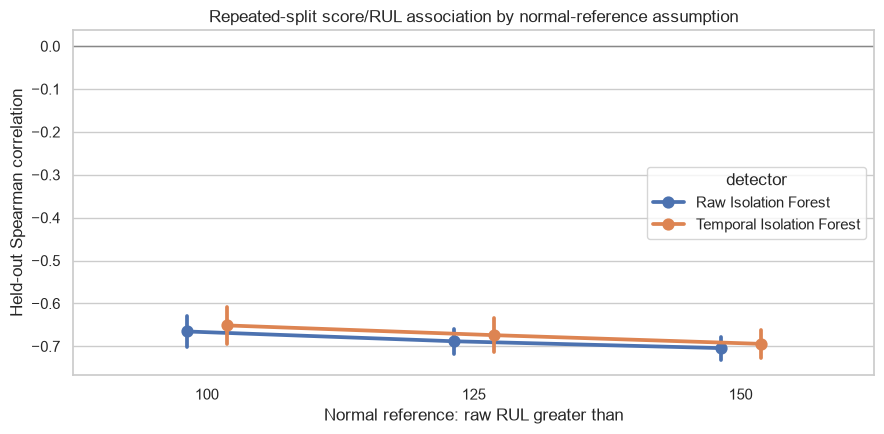

In [5]:
spearman_summary = (metrics.groupby(["reference_cutoff", "detector"])["spearman"]
    .agg(["mean", "std", "min", "max"]).round(4))
display(spearman_summary)

baseline_lifecycle = (metrics[metrics.reference_cutoff == BASELINE_REFERENCE]
    .groupby("detector")[[f"median_{s}" for s in STAGE_ORDER] + ["critical_minus_healthy"]]
    .agg(["mean", "std"]).round(4))
display(baseline_lifecycle)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.pointplot(data=metrics, x="reference_cutoff", y="spearman", hue="detector", errorbar="sd", dodge=.15, ax=ax)
ax.axhline(0, color="#888", lw=1); ax.set_title("Repeated-split score/RUL association by normal-reference assumption")
ax.set_xlabel("Normal reference: raw RUL greater than"); ax.set_ylabel("Held-out Spearman correlation")
plt.tight_layout(); plt.show()

## 6. Normal-Reference Sensitivity

Reference row counts and score behavior are reported for all three assumptions. Variation is evidence about sensitivity—not a license to label the best-looking held-out result optimal.

In [6]:
reference_summary = (metrics.groupby(["reference_cutoff", "detector"])
    .agg(normal_rows_mean=("normal_rows", "mean"), normal_rows_min=("normal_rows", "min"), normal_rows_max=("normal_rows", "max"),
         contributing_units_min=("normal_units", "min"), spearman_mean=("spearman", "mean"), spearman_std=("spearman", "std"),
         separation_mean=("critical_minus_healthy", "mean"), separation_std=("critical_minus_healthy", "std")).round(4))
display(reference_summary)

raw_stage_distributions = metrics[metrics.detector == "Raw Isolation Forest"].groupby("reference_cutoff")[[f"median_{s}" for s in STAGE_ORDER]].agg(["mean", "std"]).round(4)
display(raw_stage_distributions)

normal_rows_mean  normal_rows_min  \
reference_cutoff detector                                                       
100              Raw Isolation Forest                 8426.8             8028   
                 Temporal Isolation Forest            8426.8             8028   
125              Raw Isolation Forest                 6426.8             6028   
                 Temporal Isolation Forest            6426.8             6028   
150              Raw Isolation Forest                 4488.0             4104   
                 Temporal Isolation Forest            4488.0             4104   

                                            normal_rows_max  \
reference_cutoff detector                                     
100              Raw Isolation Forest                  8686   
                 Temporal Isolation Forest             8686   
125              Raw Isolation Forest                  6686   
                 Temporal Isolation Forest             6686   
150              Raw Isolation Forest                  4747   
                 Temporal Isolation Forest             4747   

                                            contributing_units_min  \
reference_cutoff detector                                            
100              Raw Isolation Forest                           80   
                 Temporal Isolation Forest                      80   
125              Raw Isolation Forest                           80   
                 Temporal Isolation Forest                      80   
150              Raw Isolation Forest                           73   
                 Temporal Isolation Forest                      73   

                                            spearman_mean  spearman_std  \
reference_cutoff detector                                                 
100              Raw Isolation Forest             -0.6654        0.0354   
                 Temporal Isolation Forest        -0.6513        0.0427   
125              Raw Isolation Forest             -0.6882        0.0288   
                 Temporal Isolation Forest        -0.6740        0.0396   
150              Raw Isolation Forest             -0.7042        0.0268   
                 Temporal Isolation Forest        -0.6943        0.0332   

                                            separation_mean  separation_std  
reference_cutoff detector                                                    
100              Raw Isolation Forest                0.2373          0.0118  
                 Temporal Isolation Forest           0.2059          0.0118  
125              Raw Isolation Forest                0.2398          0.0095  
                 Temporal Isolation Forest           0.2047          0.0081  
150              Raw Isolation Forest                0.2421          0.0108  
                 Temporal Isolation Forest           0.2084          0.0079

median_Healthy / early         median_Degrading          \
                                   mean     std             mean     std   
reference_cutoff                                                           
100                              0.4457  0.0075           0.4591  0.0050   
125                              0.4460  0.0064           0.4644  0.0058   
150                              0.4479  0.0077           0.4707  0.0062   

                 median_Near failure         median_Critical late life          
                                mean     std                      mean     std  
reference_cutoff                                                                
100                           0.5534  0.0066                    0.6830  0.0056  
125                           0.5641  0.0075                    0.6858  0.0054  
150                           0.5734  0.0080                    0.6900  0.0035

## 7. Quantile Threshold and Alert-Rate Stability

Numeric boundaries can move as different engines define normal behavior. Tables below summarize this movement and held-out lifecycle alert rates across splits. The 95%, 97.5%, and 99% candidates remain neutral until the complete evidence is considered.

In [7]:
baseline_thresholds = thresholds[thresholds.reference_cutoff == BASELINE_REFERENCE]
threshold_stability = (baseline_thresholds.groupby(["detector", "quantile"]).threshold
    .agg(["median", "mean", "std", "min", "max"]))
threshold_stability["range"] = threshold_stability["max"] - threshold_stability["min"]
display(threshold_stability.round(5))

baseline_alerts = alerts[alerts.reference_cutoff == BASELINE_REFERENCE]
alert_stability = baseline_alerts.groupby(["detector", "quantile", "stage"]).alert_rate_pct.agg(["mean", "std"]).round(2)
display(alert_stability)

raw_alert_sensitivity = (alerts[alerts.detector == "Raw Isolation Forest"]
    .groupby(["reference_cutoff", "quantile", "stage"]).alert_rate_pct.agg(["mean", "std"]).round(2))
display(raw_alert_sensitivity)

median     mean      std      min  \
detector                  quantile                                       
Raw Isolation Forest      0.950     0.50371  0.50401  0.00239  0.50163   
                          0.975     0.51862  0.51789  0.00314  0.51392   
                          0.990     0.53252  0.53413  0.00503  0.52955   
Temporal Isolation Forest 0.950     0.50031  0.49894  0.00222  0.49555   
                          0.975     0.51285  0.51188  0.00195  0.50939   
                          0.990     0.52837  0.52743  0.00220  0.52372   

                                        max    range  
detector                  quantile                    
Raw Isolation Forest      0.950     0.50788  0.00624  
                          0.975     0.52226  0.00834  
                          0.990     0.54206  0.01251  
Temporal Isolation Forest 0.950     0.50068  0.00514  
                          0.975     0.51391  0.00452  
                          0.990     0.52930  0.00559

mean   std
detector                  quantile stage                          
Raw Isolation Forest      0.950    Critical late life  99.77  0.27
                                   Degrading           24.85  3.82
                                   Healthy / early      5.93  1.63
                                   Near failure        77.90  5.40
                          0.975    Critical late life  99.65  0.42
                                   Degrading           18.54  4.19
                                   Healthy / early      2.85  1.03
                                   Near failure        72.77  5.71
                          0.990    Critical late life  99.23  0.78
                                   Degrading           12.88  4.57
                                   Healthy / early      1.15  0.73
                                   Near failure        65.47  6.09
Temporal Isolation Forest 0.950    Critical late life  99.87  0.21
                                   Degrading           26.00  6.71
                                   Healthy / early      6.46  3.22
                                   Near failure        76.60  7.25
                          0.975    Critical late life  99.58  0.53
                                   Degrading           20.72  6.12
                                   Healthy / early      3.24  1.91
                                   Near failure        72.27  7.95
                          0.990    Critical late life  99.32  0.79
                                   Degrading           15.71  5.15
                                   Healthy / early      1.37  1.06
                                   Near failure        65.53  7.48

mean   std
reference_cutoff quantile stage                          
100              0.950    Critical late life  99.58  0.37
                          Degrading           18.95  3.51
                          Healthy / early      4.83  0.88
                          Near failure        72.73  5.29
                 0.975    Critical late life  99.32  0.64
                          Degrading           13.75  4.23
                          Healthy / early      2.21  0.74
                          Near failure        66.93  5.23
                 0.990    Critical late life  99.00  0.94
                          Degrading            9.75  3.92
                          Healthy / early      0.81  0.32
                          Near failure        59.50  5.08
125              0.950    Critical late life  99.77  0.27
                          Degrading           24.85  3.82
                          Healthy / early      5.93  1.63
                          Near failure        77.90  5.40
                 0.975    Critical late life  99.65  0.42
                          Degrading           18.54  4.19
                          Healthy / early      2.85  1.03
                          Near failure        72.77  5.71
                 0.990    Critical late life  99.23  0.78
                          Degrading           12.88  4.57
                          Healthy / early      1.15  0.73
                          Near failure        65.47  6.09
150              0.950    Critical late life  99.94  0.09
                          Degrading           28.68  4.27
                          Healthy / early      7.00  2.46
                          Near failure        80.23  5.58
                 0.975    Critical late life  99.71  0.35
                          Degrading           22.72  4.63
                          Healthy / early      3.79  1.90
                          Near failure        75.77  5.85
                 0.990    Critical late life  99.52  0.47
                          Degrading           15.89  4.17
                          Healthy / early      1.78  1.09
                          Near failure        68.77  5.50

## 8. Engine-Level Coverage and Retrospective Lead Time

Observation rates can conceal engine instability. For each split and candidate threshold, the notebook reports engines ever alerting, engines alerting during critical late life, engines with premature healthy-stage alerts, and first-alert lead time (`raw_rul` at first crossing). Lead time is retrospective and not guaranteed warning time.

In [8]:
engine_records, lead_records = [], []
for seed in SEEDS:
    for detector_name in ["Raw Isolation Forest", "Temporal Isolation Forest"]:
        item = split_cache[seed][(BASELINE_REFERENCE, detector_name)]
        scored = item["scored"]
        total_units = scored.unit_id.nunique()
        for q, threshold in item["threshold_by_q"].items():
            flagged = scored.assign(alert=scored.score > threshold)
            ever = flagged.groupby("unit_id").alert.any()
            critical = flagged[flagged.lifecycle_stage == "Critical late life"].groupby("unit_id").alert.any().reindex(ever.index, fill_value=False)
            healthy = flagged[flagged.lifecycle_stage == "Healthy / early"].groupby("unit_id").alert.any().reindex(ever.index, fill_value=False)
            density = flagged.groupby("unit_id").alert.mean()
            engine_records.append({"seed": seed, "detector": detector_name, "quantile": q,
                "ever_alert_coverage_pct": 100*ever.mean(), "critical_engine_coverage_pct": 100*critical.mean(),
                "premature_healthy_engine_pct": 100*healthy.mean(), "mean_alert_density_pct": 100*density.mean()})
            for unit, group in flagged.groupby("unit_id"):
                first = group[group.alert].sort_values("cycle").head(1)
                lead_records.append({"seed": seed, "detector": detector_name, "quantile": q, "unit_id": unit,
                                     "alerted": not first.empty, "lead_time": np.nan if first.empty else float(first.raw_rul.iloc[0])})

engine_metrics = pd.DataFrame(engine_records)
lead_times = pd.DataFrame(lead_records)
engine_value_columns = ["ever_alert_coverage_pct", "critical_engine_coverage_pct", "premature_healthy_engine_pct", "mean_alert_density_pct"]
engine_summary = engine_metrics.groupby(["detector", "quantile"])[engine_value_columns].agg(["mean", "std"]).round(2)
display(engine_summary)

def summarize_leads(group):
    values = group.lead_time.dropna()
    return pd.Series({"engines": len(group), "never_alerted": group.alerted.eq(False).sum(), "median": values.median(),
                      "q25": values.quantile(.25), "q75": values.quantile(.75), "min": values.min(), "max": values.max(),
                      "very_early_over_125": (values > 125).sum()})
lead_summary = lead_times.groupby(["detector", "quantile"]).apply(summarize_leads, include_groups=False).round(2)
display(lead_summary)

ever_alert_coverage_pct       \
                                                      mean  std   
detector                  quantile                                
Raw Isolation Forest      0.950                      100.0  0.0   
                          0.975                      100.0  0.0   
                          0.990                      100.0  0.0   
Temporal Isolation Forest 0.950                      100.0  0.0   
                          0.975                      100.0  0.0   
                          0.990                      100.0  0.0   

                                   critical_engine_coverage_pct       \
                                                           mean  std   
detector                  quantile                                     
Raw Isolation Forest      0.950                           100.0  0.0   
                          0.975                           100.0  0.0   
                          0.990                           100.0  0.0   
Temporal Isolation Forest 0.950                           100.0  0.0   
                          0.975                           100.0  0.0   
                          0.990                           100.0  0.0   

                                   premature_healthy_engine_pct         \
                                                           mean    std   
detector                  quantile                                       
Raw Isolation Forest      0.950                            62.0  14.40   
                          0.975                            51.0  12.45   
                          0.990                            30.0  10.61   
Temporal Isolation Forest 0.950                            53.0  10.95   
                          0.975                            42.0   5.70   
                          0.990                            29.0  10.84   

                                   mean_alert_density_pct        
                                                     mean   std  
detector                  quantile                               
Raw Isolation Forest      0.950                     37.10  2.99  
                          0.975                     33.13  2.84  
                          0.990                     29.50  3.04  
Temporal Isolation Forest 0.950                     37.58  4.96  
                          0.975                     34.00  4.49  
                          0.990                     30.57  3.85

engines  never_alerted  median     q25  \
detector                  quantile                                           
Raw Isolation Forest      0.950       100.0            0.0   146.0  104.00   
                          0.975       100.0            0.0   126.0   74.75   
                          0.990       100.0            0.0    80.5   54.00   
Temporal Isolation Forest 0.950       100.0            0.0   128.5   87.50   
                          0.975       100.0            0.0   108.0   60.75   
                          0.990       100.0            0.0    74.5   51.00   

                                       q75   min    max  very_early_over_125  
detector                  quantile                                            
Raw Isolation Forest      0.950     202.25  34.0  291.0                 62.0  
                          0.975     179.00  28.0  291.0                 51.0  
                          0.990     143.50  26.0  266.0                 30.0  
Temporal Isolation Forest 0.950     202.00  33.0  291.0                 53.0  
                          0.975     179.75  27.0  291.0                 42.0  
                          0.990     135.50  26.0  281.0                 29.0

## 9. Backward-Looking Persistence Experiment

At the provisional 97.5th-percentile boundary, three raw-detector policies are compared: one cycle above threshold, two consecutive cycles above threshold, and three of the latest five cycles above threshold. Rolling logic is grouped by engine and uses only current/past flags. The experiment does not freeze a policy.

In [9]:
def persistence_flags(scored, threshold):
    out = scored.sort_values(["unit_id", "cycle"]).copy()
    out["above"] = out.score > threshold
    grouped = out.groupby("unit_id", sort=False).above
    out["1 cycle"] = out.above
    out["2 consecutive"] = out.above & grouped.shift(1).fillna(False)
    out["3 of last 5"] = grouped.transform(lambda x: x.rolling(5, min_periods=1).sum().ge(3))
    return out

persistence_records=[]
for seed in SEEDS:
    item = split_cache[seed][(BASELINE_REFERENCE, "Raw Isolation Forest")]
    flagged = persistence_flags(item["scored"], item["threshold_by_q"][.975])
    for policy in ["1 cycle", "2 consecutive", "3 of last 5"]:
        engine_any = flagged.groupby("unit_id")[policy].any()
        critical_any = flagged[flagged.lifecycle_stage == "Critical late life"].groupby("unit_id")[policy].any().reindex(engine_any.index, fill_value=False)
        healthy_any = flagged[flagged.lifecycle_stage == "Healthy / early"].groupby("unit_id")[policy].any().reindex(engine_any.index, fill_value=False)
        healthy_rate = 100*flagged.loc[flagged.lifecycle_stage == "Healthy / early", policy].mean()
        critical_rate = 100*flagged.loc[flagged.lifecycle_stage == "Critical late life", policy].mean()
        leads=[]
        for unit, group in flagged.groupby("unit_id"):
            first=group[group[policy]].head(1)
            if not first.empty: leads.append(float(first.raw_rul.iloc[0]))
        persistence_records.append({"seed": seed, "policy": policy, "healthy_observation_alert_pct": healthy_rate,
            "critical_observation_alert_pct": critical_rate, "ever_engine_coverage_pct": 100*engine_any.mean(),
            "critical_engine_coverage_pct": 100*critical_any.mean(), "premature_healthy_engine_pct": 100*healthy_any.mean(),
            "median_lead_time": np.median(leads) if leads else np.nan})

persistence = pd.DataFrame(persistence_records)
persistence_value_columns = [c for c in persistence.columns if c not in ["seed", "policy"]]
persistence_summary = persistence.groupby("policy")[persistence_value_columns].agg(["mean", "std"]).round(2)
display(persistence_summary)

# Direct no-future checks for a synthetic sequence.
probe = pd.DataFrame({"unit_id":[1]*6, "cycle":range(1,7), "raw_rul":range(5,-1,-1), "score":[0,1,1,0,1,1], "lifecycle_stage":["Critical late life"]*6})
probe_flags = persistence_flags(probe, .5)
assert probe_flags["2 consecutive"].tolist() == [False, False, True, False, False, True]
assert probe_flags["3 of last 5"].tolist() == [False, False, False, False, True, True]
print("Persistence logic validated as current/past only.")

healthy_observation_alert_pct        \
                                       mean   std   
policy                                              
1 cycle                                2.85  1.03   
2 consecutive                          0.41  0.35   
3 of last 5                            0.54  0.44   

              critical_observation_alert_pct       ever_engine_coverage_pct  \
                                        mean   std                     mean   
policy                                                                        
1 cycle                                99.65  0.42                    100.0   
2 consecutive                          99.23  0.78                    100.0   
3 of last 5                            99.61  0.53                    100.0   

                   critical_engine_coverage_pct       \
               std                         mean  std   
policy                                                 
1 cycle        0.0                        100.0  0.0   
2 consecutive  0.0                        100.0  0.0   
3 of last 5    0.0                        100.0  0.0   

              premature_healthy_engine_pct        median_lead_time         
                                      mean    std             mean    std  
policy                                                                     
1 cycle                               51.0  12.45            121.3  25.58  
2 consecutive                         10.0   3.54             63.7   3.51  
3 of last 5                            7.0   2.74             59.8   2.39

Persistence logic validated as current/past only.


## 10. Statistical-Distance Reference

For context, the interpretable root-mean-square standardized distance baseline is repeated across the five `raw_rul > 125` splits. It uses the same training-normal-only scaler and higher-is-more-anomalous direction.

In [10]:
stat_records=[]
for seed in SEEDS:
    cache=split_cache[seed]
    train=df[df.unit_id.isin(cache["train_units"])]
    held=df[df.unit_id.isin(cache["held_units"])]
    normal=train[train.raw_rul > BASELINE_REFERENCE]
    scaler=StandardScaler().fit(normal[RAW_FEATURES])
    train_z=scaler.transform(normal[RAW_FEATURES]); held_z=scaler.transform(held[RAW_FEATURES])
    train_score=np.sqrt(np.mean(train_z**2, axis=1)); held_score=np.sqrt(np.mean(held_z**2, axis=1))
    threshold=np.quantile(train_score,.975)
    stage=held.lifecycle_stage
    stat_records.append({"seed":seed,"spearman":spearmanr(held_score,held.raw_rul).statistic,
        "healthy_alert_pct":100*np.mean(held_score[stage=="Healthy / early"]>threshold),
        "critical_alert_pct":100*np.mean(held_score[stage=="Critical late life"]>threshold)})
statistical_summary=pd.DataFrame(stat_records).drop(columns="seed").agg(["mean","std","min","max"]).round(4)
display(statistical_summary)

,spearman,healthy_alert_pct,critical_alert_pct
mean,-0.6832,3.0479,99.9032
std,0.0293,1.4204,0.0883
min,-0.7289,1.0984,99.8387
max,-0.6564,5.0306,100.0000


## 11. Training-Score Distribution and 0–100 Design

Training-normal score quantiles show whether the native scale is stable. A possible 0–100 representation maps an observation to its empirical percentile within the corresponding training-normal distribution. It means “more unusual than approximately X% of the development normal-reference scores,” not probability. Mapping remains exploratory and uses no held-out data for its definition.

In [11]:
score_scale_summary = score_distributions.groupby(["detector", "quantile"]).training_score.agg(["mean","std","min","max"]).round(5)
display(score_scale_summary)

percentile_records=[]
for seed in SEEDS:
    for detector_name in ["Raw Isolation Forest", "Temporal Isolation Forest"]:
        item=split_cache[seed][(BASELINE_REFERENCE,detector_name)]
        ordered=np.sort(item["train_scores"])
        scored=item["scored"].copy()
        scored["percentile_score"]=100*np.searchsorted(ordered,scored.score,side="right")/len(ordered)
        for stage in STAGE_ORDER:
            values=scored.loc[scored.lifecycle_stage==stage,"percentile_score"]
            percentile_records.append({"seed":seed,"detector":detector_name,"stage":stage,"median_percentile":values.median()})
percentile_stability=pd.DataFrame(percentile_records).groupby(["detector","stage"]).median_percentile.agg(["mean","std","min","max"]).round(2)
display(percentile_stability)

mean      std      min      max
detector                  quantile                                    
Raw Isolation Forest      0.500     0.44408  0.00080  0.44334  0.44496
                          0.900     0.48974  0.00198  0.48718  0.49226
                          0.950     0.50401  0.00239  0.50163  0.50788
                          0.975     0.51789  0.00314  0.51392  0.52226
                          0.990     0.53413  0.00503  0.52955  0.54206
                          1.000     0.60096  0.00870  0.59140  0.61063
Temporal Isolation Forest 0.500     0.44396  0.00100  0.44276  0.44493
                          0.900     0.48445  0.00191  0.48163  0.48621
                          0.950     0.49894  0.00222  0.49555  0.50068
                          0.975     0.51188  0.00195  0.50939  0.51391
                          0.990     0.52743  0.00220  0.52372  0.52930
                          1.000     0.58557  0.00797  0.57506  0.59698

mean   std     min     max
detector                  stage                                           
Raw Isolation Forest      Critical late life  100.00  0.00  100.00  100.00
                          Degrading            72.74  4.79   67.25   78.88
                          Healthy / early      52.19  7.74   44.04   63.08
                          Near failure         99.82  0.14   99.58   99.94
Temporal Isolation Forest Critical late life  100.00  0.00  100.00  100.00
                          Degrading            71.22  6.07   63.47   78.93
                          Healthy / early      54.58  7.14   45.59   65.13
                          Near failure         99.86  0.14   99.64   99.98

## 12. Sensor-Deviation Context for Future UI

For three mechanically selected high-anomaly observations from the seed-42 baseline split, the largest absolute standardized sensor deviations are reported. Suitable future wording is **“Most unusual sensor readings relative to normal reference.”** These are not Isolation Forest feature importances or causal explanations.

In [12]:
example=split_cache[42][(BASELINE_REFERENCE,"Raw Isolation Forest")]
example_scored=example["scored"].copy()
positions=np.argsort(example_scored.score.to_numpy())[-3:][::-1]
example_raw=df[df.unit_id.isin(split_cache[42]["held_units"])].copy()
z=np.abs(example["scaler"].transform(example_raw[RAW_FEATURES]))
explanation_rows=[]
for rank,pos in enumerate(positions,1):
    deviations=pd.Series(z[pos],index=RAW_FEATURES).sort_values(ascending=False).head(5)
    row=example_scored.iloc[pos]
    for sensor,value in deviations.items():
        explanation_rows.append({"example_rank":rank,"unit_id":int(row.unit_id),"cycle":int(row.cycle),"raw_rul_evaluation":int(row.raw_rul),
                                 "anomaly_score":row.score,"sensor":sensor,"absolute_standardized_deviation":value})
sensor_context=pd.DataFrame(explanation_rows)
display(sensor_context.round(3))

,example_rank,unit_id,cycle,raw_rul_evaluation,anomaly_score,sensor,absolute_standardized_deviation
0,1,40,188,0,0.732,sensor_9,10.039
1,1,40,188,0,0.732,sensor_14,8.085
2,1,40,188,0,0.732,sensor_3,5.343
3,1,40,188,0,0.732,sensor_4,5.094
4,1,40,188,0,0.732,sensor_7,4.661
5,2,45,158,0,0.732,sensor_4,5.937
6,2,45,158,0,0.732,sensor_20,5.498
7,2,45,158,0,0.732,sensor_11,5.418
8,2,45,158,0,0.732,sensor_15,4.970
9,2,45,158,0,0.732,sensor_9,4.463


## 13. Leakage and Reproducibility Audit

In [13]:
all_features=set(RAW_FEATURES)|set(TEMPORAL_FEATURES)
assert not {"unit_id","cycle","raw_rul","RUL","capped_rul","final_lifetime"}.intersection(all_features)
for seed in SEEDS:
    assert split_cache[seed]["train_units"].isdisjoint(split_cache[seed]["held_units"])
assert (thresholds.source=="training normal only").all()
assert TRAIN_PATH.name=="train_FD001.txt"
assert not any(Path("../models").glob("*anomaly*"))
assert len(metrics)==len(SEEDS)*len(REFERENCE_CUTOFFS)*2
print("PASS: five repeated splits have zero unit overlap.")
print("PASS: every scaler and detector was fitted on development training-normal rows only.")
print("PASS: RUL, cycle, identity, and targets are absent from predictor contracts.")
print("PASS: all candidate thresholds derive from training-normal scores only.")
print("PASS: temporal and persistence logic is unit-aware and backward-looking.")
print("PASS: no official test labels were loaded; no anomaly artifact was serialized.")

PASS: five repeated splits have zero unit overlap.
PASS: every scaler and detector was fitted on development training-normal rows only.
PASS: RUL, cycle, identity, and targets are absent from predictor contracts.
PASS: all candidate thresholds derive from training-normal scores only.
PASS: temporal and persistence logic is unit-aware and backward-looking.
PASS: no official test labels were loaded; no anomaly artifact was serialized.


## 14. Methodological Limitations

- FD001 is simulated, with one operating condition and one fault mode.
- There are no externally validated anomaly labels.
- Early-life RUL is a retrospective proxy for healthy operation; it is not an observed health certification.
- RUL is used only for development subset construction and retrospective evaluation.
- Quantile alert boundaries are heuristics, and lead times are retrospective rather than guaranteed.
- Repeated splits reduce dependence on one partition but do not establish external validity.
- Real industrial deployment requires validated normal/fault data, sensor-quality controls, operating-regime handling, drift monitoring, and safety governance.
- This is condition-monitoring research, not safety certification.

## Anomaly Detection Refinement Conclusions

Across five zero-overlap 80/20 unit splits, the raw Isolation Forest retained a consistently negative score/RUL relationship at the baseline `raw_rul > 125` reference (mean Spearman −0.688, SD 0.029, range −0.729 to −0.654). Its mean critical-minus-healthy median score separation was 0.240. The temporal detector was weaker and less stable (mean −0.674, SD 0.040; separation 0.205), while the statistical baseline remained competitive but slightly weaker at mean Spearman −0.683. The added temporal complexity is therefore not justified for v1.

Normal-reference sensitivity preserves the same directional signal from cutoffs 100 through 150, but the assumptions have different meaning: `>100` includes rows classified as degrading by the fixed evaluation bins, while `>150` excludes some shorter-lived development engines and raises healthy-stage alert burden. The middle `raw_rul > 125` policy remains the most defensible research reference rather than an empirically optimized winner. At this reference, raw-detector numeric thresholds were reasonably stable: ranges were 0.0062, 0.0083, and 0.0125 for the 95th, 97.5th, and 99th percentiles.

The provisional 97.5th-percentile raw policy averaged 2.85% healthy observation alerts, 99.65% critical observation alerts, and 100% critical-stage engine coverage. However, a one-cycle policy produced premature healthy-stage alerts in 51% of engines and a median first-alert lead time averaging 121 cycles, demonstrating spike noise. Backward-looking 3-of-5 persistence reduced healthy observation alerts to 0.54% and premature healthy-engine alerts to 7%, retained 100% critical-stage engine coverage and 99.61% critical observation coverage, and produced a more plausible mean median lead time of about 60 cycles. It is recommended as a provisional alert rule for finalization, not a frozen safety threshold.

**Recommended v1 research specification:** raw Isolation Forest; 14 retained sensors; normal reference `raw_rul > 125`; provisional 97.5th training-normal percentile; 3-of-5 backward-looking persistence; empirical normal-reference percentile as a non-probabilistic 0–100 score; and standardized sensor deviations described as “most unusual sensor readings relative to normal reference.” The percentile mapping appears viable because training-score quantiles are fairly stable, but it still requires versioning with its fitted reference distribution. Nothing is serialized here.

The main limitations remain simulated single-condition/single-fault data, retrospective healthy proxies and lead times, no true anomaly labels, and no external validation or drift evidence.

**Verdict: A) Anomaly Detection v1 methodology is stable enough to freeze and move to model finalization / production refactor.**

**Recommended next step:** `notebooks/13_anomaly_model_finalization.ipynb`—do not create it yet.